# Phase 1: Exploratory Data Analysis (EDA) on KITTI Dataset
## Project: Urban Object Detection for Autonomous Driving

**Authors:** Shamim Sedaghat Teimouri & Mahdi Salman

### 1. Introduction
In this notebook, we perform a comprehensive Exploratory Data Analysis (EDA) on the KITTI object detection dataset. The goal is to understand the underlying characteristics of the data, which is crucial for designing an effective preprocessing pipeline and selecting the appropriate model architecture (YOLOv8).

**Objectives:**
1.  Analyze class distribution to identify potential imbalances.
2.  Examine bounding box dimensions to understand object scales.
3.  Visualize spatial distribution to identify regions of interest (ROI).
4.  Assess scene complexity (crowdedness).

### 2. Data Loading & Parsing
We start by loading the dataset labels. The labels are in YOLO format (class_id, x_center, y_center, width, height), all normalized between 0 and 1. We parse these files and store the attributes in lists for further analysis.

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Configuration
labels_path = '../data/labels/train'
class_names = ['Car', 'Van', 'Truck', 'Pedestrian', 'Person_sitting', 'Cyclist', 'Tram', 'Misc']

# Data Containers
all_classes = []
all_widths = []
all_heights = []
all_centers_x = []
all_centers_y = []
objects_per_image = []

# Load Data
label_files = os.listdir(labels_path)
print(f"Loading data from {len(label_files)} files...")

for label_file in label_files:
    path = os.path.join(labels_path, label_file)
    with open(path, 'r') as f:
        lines = f.readlines()
        
    valid_objs = 0
    for line in lines:
        parts = line.strip().split()
        if len(parts) != 5: continue
        
        # Parse Class ID
        cls_id = int(parts[0])
        if cls_id < len(class_names):
            all_classes.append(class_names[cls_id])
        
        # Parse Coordinates (Normalized)
        x, y, w, h = map(float, parts[1:])
        all_centers_x.append(x)
        all_centers_y.append(y)
        all_widths.append(w)
        all_heights.append(h)
        valid_objs += 1
        
    objects_per_image.append(valid_objs)

print("Data loading complete.")

### 3. Class Distribution Analysis
**Why is this important?**
Deep learning models tend to be biased towards the majority class. In urban datasets like KITTI, we often see significantly more cars than pedestrians or cyclists.

**Analysis:**
The chart below displays the frequency of each object category. A severe imbalance (e.g., ratio > 1:10) suggests that we might need to use techniques like **Weighted Loss** or **Focal Loss** during training, or apply class-specific data augmentation.

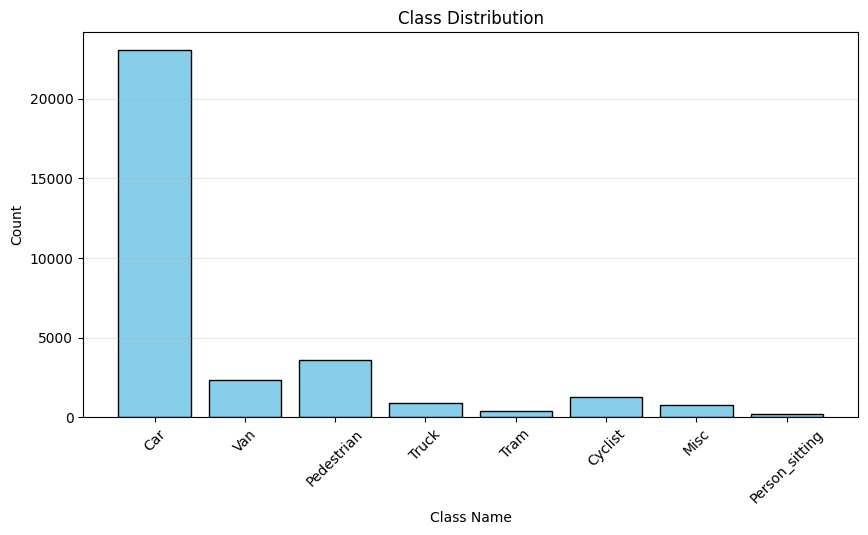

In [ ]:
plt.figure(figsize=(12, 6))
counts = Counter(all_classes)
# Sort for better visualization
sorted_counts = dict(sorted(counts.items(), key=lambda item: item[1], reverse=True))

bars = plt.bar(sorted_counts.keys(), sorted_counts.values(), color='skyblue', edgecolor='black', alpha=0.8)
plt.title('Distribution of Object Classes in Training Set', fontsize=14)
plt.xlabel('Class Name', fontsize=12)
plt.ylabel('Number of Instances', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height}',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()